In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np
import scienceplots
from scipy.stats import linregress
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
%matplotlib inline

# ---------------------------------------------------------------------------
#  Matplotlib Styles
# ---------------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,

    "axes.labelsize": 14,     # x and y axis titles
    "xtick.labelsize": 12,    # x tick numbers / category labels
    "ytick.labelsize": 12,    # y tick numbers
    "axes.titlesize": 14,     # plot titles
    "legend.fontsize": 11,    # legends
})
# ---------------------------------------------------------------------------
#  Load Data
# ---------------------------------------------------------------------------

EXCEL_PATH = r"C:\Users\mouly\Dropbox\Codes and Dataset\Field_Vertical.xlsx"

1.0_O2 sites    : 47
0.1_O2 sites    : 35
0.5_O2 sites    : 43
0.5_All sites   : 36


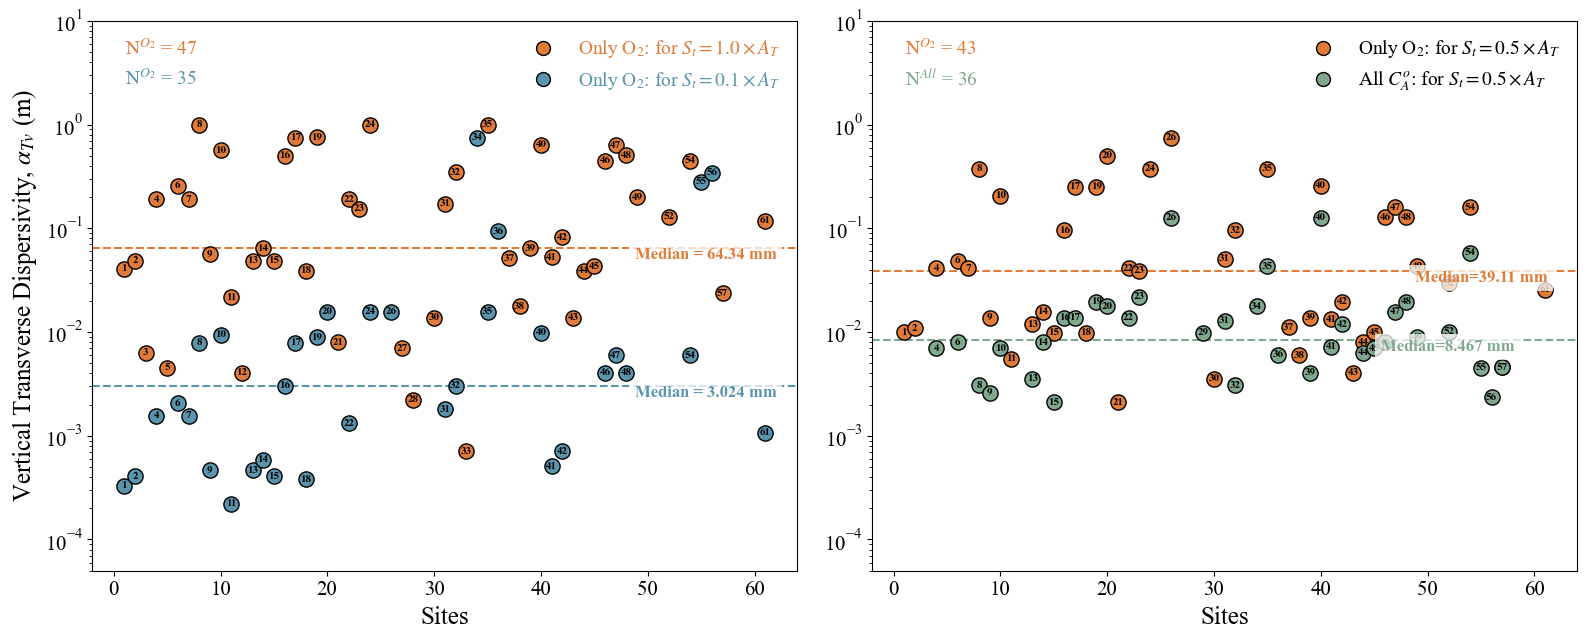

In [33]:
# ---------------------------------------------------------------------------
# Load & Clean
# ---------------------------------------------------------------------------
def clean(df):
    df["Site_ID"] = pd.to_numeric(df["Site_ID"], errors="coerce")
    df["atv"] = pd.to_numeric(df["atv"], errors="coerce")
    df = df.dropna(subset=["Site_ID", "atv"]).reset_index(drop=True)
    df["Site_ID"] = df["Site_ID"].astype(int)
    return df

df_10     = clean(pd.read_excel(EXCEL_PATH, sheet_name="1.0_O2"))
df_01     = clean(pd.read_excel(EXCEL_PATH, sheet_name="0.1_O2"))
df_05_O2  = clean(pd.read_excel(EXCEL_PATH, sheet_name="0.5_O2"))
df_05_All = clean(pd.read_excel(EXCEL_PATH, sheet_name="0.5_All"))

# ---------------------------------------------------------------------------
# Save totals (all sites retained)
# ---------------------------------------------------------------------------
n_10_total     = df_10["Site_ID"].nunique()
n_01_total     = df_01["Site_ID"].nunique()
n_05_O2_total  = df_05_O2["Site_ID"].nunique()
n_05_All_total = df_05_All["Site_ID"].nunique()

print(f"1.0_O2 sites    : {n_10_total}")
print(f"0.1_O2 sites    : {n_01_total}")
print(f"0.5_O2 sites    : {n_05_O2_total}")
print(f"0.5_All sites   : {n_05_All_total}")

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6.5))

# ===========================================================================
# LEFT PANEL: 1.0_O2 vs 0.1_O2
# ===========================================================================

ax1.scatter(
    df_10["Site_ID"],
    df_10["atv"],
    color="#E07B39",
    edgecolors="k",
    s=120,
    zorder=3
)

for _, row in df_10.iterrows():
    ax1.text(
        row["Site_ID"],
        row["atv"],
        str(int(row["Site_ID"])),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold"
    )

ax1.scatter(
    df_01["Site_ID"],
    df_01["atv"],
    color="#5A94AD",
    edgecolors="k",
    s=120,
    zorder=3
)

for _, row in df_01.iterrows():
    ax1.text(
        row["Site_ID"],
        row["atv"],
        str(int(row["Site_ID"])),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold"
    )

# Median lines
median_10 = df_10["atv"].median()
median_01 = df_01["atv"].median()

ax1.axhline(
    median_10,
    color="#E07B39",
    linestyle="--",
    linewidth=1.5
)

ax1.axhline(
    median_01,
    color="#5A94AD",
    linestyle="--",
    linewidth=1.5
)

ax1.text(
    max(df_10["Site_ID"])*0.8,
    median_10*0.78,
    f"Median = {median_10*1000:.4g} mm",
    color="#E07B39",
    fontsize=12,fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
)

ax1.text(
    max(df_01["Site_ID"])*0.8,
    median_01*0.78,
    f"Median = {median_01*1000:.4g} mm",
    color="#5A94AD",
    fontsize=12,fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
)

ax1.set_yscale("log")
ax1.set_ylim(5e-5,10)

ax1.set_xlabel("Sites",fontsize=18)
ax1.set_ylabel(
    r"Vertical Transverse Dispersivity, $\alpha_{Tv}$ (m)", fontsize=18
)
ax1.tick_params(axis="both", which="both", labelsize=15)
# Right legend
handles_right_1 = [
    mlines.Line2D(
        [],[],color="#E07B39",
        marker="o",
        markeredgecolor="k",
        linestyle="None",
        markersize=10,
        label=rf"Only O$_2$: for $S_t = 1.0\times A_T$"
    ),

    mlines.Line2D(
        [],[],color="#5A94AD",
        marker="o",
        markeredgecolor="k",
        linestyle="None",
        markersize=10,
        label=rf"Only O$_2$: for $S_t = 0.1\times A_T$"
    )
]

leg_right_1=ax1.legend(
    handles=handles_right_1,
    loc="upper right",
    frameon=False,
    fontsize=14
)

for text,color in zip(
    leg_right_1.get_texts(),
    ["#E07B39","#5A94AD"]
):
    text.set_color(color)

# Left legend
handles_left_1 = [
    mlines.Line2D(
        [],[],
        marker="None",
        linestyle="None",
        label=rf"N$^{{O_2}}$ = {n_10_total}"
    ),

    mlines.Line2D(
        [],[],
        marker="None",
        linestyle="None",
        label=rf"N$^{{O_2}}$ = {n_01_total}"
    )
]

leg_left_1=ax1.legend(
    handles=handles_left_1,
    loc="upper left",
    frameon=False,
    handlelength=0,
    fontsize=14
)

for text,color in zip(
    leg_left_1.get_texts(),
    ["#E07B39","#5A94AD"]
):
    text.set_color(color)

ax1.add_artist(leg_right_1)

# ===========================================================================
# RIGHT PANEL: 0.5_O2 vs 0.5_All
# ===========================================================================

for df,color in zip(
    [df_05_O2,df_05_All],
    ["#E07B39","#7FA88E"]
):

    ax2.scatter(
        df["Site_ID"],
        df["atv"],
        color=color,
        edgecolors="k",
        s=120,
        zorder=3
    )

    for _,row in df.iterrows():

        ax2.text(
            row["Site_ID"],
            row["atv"],
            str(int(row["Site_ID"])),
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold"
        )

median_05_O2=df_05_O2["atv"].median()
median_05_All=df_05_All["atv"].median()

ax2.axhline(
    median_05_O2,
    color="#E07B39",
    linestyle="--"
)

ax2.axhline(
    median_05_All,
    color="#7FA88E",
    linestyle="--"
)

ax2.text(
    max(df_05_O2["Site_ID"])*0.8,
    median_05_O2*0.78,
    f"Median={median_05_O2*1000:.4g} mm",
    color="#E07B39",
    fontsize=12,fontweight="bold",
    bbox=dict(facecolor="white",alpha=0.75,edgecolor="none")
)

ax2.text(
    max(df_05_All["Site_ID"])*0.8,
    median_05_All*0.78,
    f"Median={median_05_All*1000:.4g} mm",
    color="#7FA88E",
    fontsize=12,fontweight="bold",
    bbox=dict(facecolor="white",alpha=0.75,edgecolor="none")
)

ax2.set_yscale("log")
ax2.set_ylim(5e-5,10)
ax2.set_xlabel("Sites",fontsize=18)
ax2.tick_params(axis="both", which="both", labelsize=15)
handles_right_2 = [
    mlines.Line2D(
        [],[],
        color="#E07B39",
        marker="o",
        markeredgecolor="k",
        linestyle="None",
        markersize=10,
        label=rf"Only O$_2$: for $S_t = 0.5\times A_T$"
    ),

    mlines.Line2D(
        [],[],
        color="#7FA88E",
        marker="o",
        markeredgecolor="k",
        linestyle="None",
        markersize=10,
        label=rf"All $C_A^o$: for $S_t = 0.5\times A_T$"
    )
]

leg_right_2=ax2.legend(
    handles=handles_right_2,
    loc="upper right",
    frameon=False,
    fontsize=14
)

handles_left_2 = [
    mlines.Line2D(
        [],[],
        marker="None",
        linestyle="None",
        label=rf"N$^{{O_2}}$ = {n_05_O2_total}"
    ),

    mlines.Line2D(
        [],[],
        marker="None",
        linestyle="None",
        label=rf"N$^{{All}}$ = {n_05_All_total}" # [r"$N_{\mathrm{O_2}}$"]
    )
]

leg_left_2=ax2.legend(
    handles=handles_left_2,
    loc="upper left",
    frameon=False,
    handlelength=0,
    fontsize=14
)

for text,color in zip(
    leg_left_2.get_texts(),
    ["#E07B39","#7FA88E"]
):
    text.set_color(color)

ax2.add_artist(leg_right_2)

# ---------------------------------------------------------------------------
# Save and show
# ---------------------------------------------------------------------------
plt.tight_layout()
plt.savefig("fig3.pdf", dpi=300, bbox_inches="tight")
plt.show()

Pooled O2 points  (n=366):  st range [0.1000, 22.0000]
Pooled All points (n=241): st range [0.3048, 22.0000]

Inset (phi=0.4) point counts within st<=10: O2=44, All=32


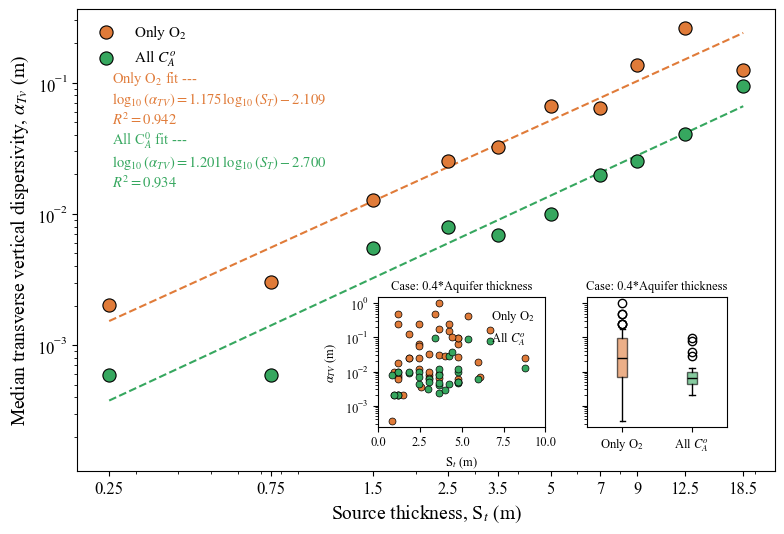

---- O2 only (pooled across ALL phi sheets, incl. N set) ----
m (slope)            = 1.1753
c (intercept)        = -2.1089
r  (correlation)     = 0.9706
r^2 (linear fit)     = 0.9421
p-value              = 3.1523e-06
Std. error of m      = 0.1030
Equation: log10(alpha_TV) = 1.1753 x log10(t) - 2.1089
(equivalent power law: alpha_TV = 0.0078 x t^1.1753)

---- All compounds (pooled across ALL phi sheets, incl. N set) ----
m (slope)            = 1.2005
c (intercept)        = -2.6999
r  (correlation)     = 0.9664
r^2 (linear fit)     = 0.9340
p-value              = 5.3249e-06
Std. error of m      = 0.1128
Equation: log10(alpha_TV) = 1.2005 x log10(t) - 2.6999
(equivalent power law: alpha_TV = 0.0020 x t^1.2005)


In [34]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
PHI_MAIN = ["0.1", "0.2", "0.4", "0.5", "0.6", "0.8", "1.0"]   # _O2 / _All sheets
PHI_N    = ["0.1", "0.25", "0.5", "0.75"]                       # _O2N / _AllN sheets

COLOR_O2  = "#E07B39"
COLOR_ALL = "#36A75F"

SELECTED_PHI = "0.4"   # used only for the inset panels below
XLIM_MAX     = 10

# ---------------------------------------------------------------------------
# Step 1-2: Load and pool O2 / All data across EVERY sheet except 'Data'----
o2_frames = (
    [pd.read_excel(EXCEL_PATH, sheet_name=f"{phi}_O2")  for phi in PHI_MAIN] +
    [pd.read_excel(EXCEL_PATH, sheet_name=f"{phi}_O2N") for phi in PHI_N]
)
all_frames = (
    [pd.read_excel(EXCEL_PATH, sheet_name=f"{phi}_All")  for phi in PHI_MAIN] +
    [pd.read_excel(EXCEL_PATH, sheet_name=f"{phi}_AllN") for phi in PHI_N]
)

df_o2  = pd.concat(o2_frames,  ignore_index=True)
df_all = pd.concat(all_frames, ignore_index=True)

# ---------------------------------------------------------------------------
# Step 3: Clean both dataframes
# ---------------------------------------------------------------------------
def clean(df):
    df = df.copy()
    df["Site_ID"] = pd.to_numeric(df["Site_ID"], errors="coerce")
    df["st"] = pd.to_numeric(df["st"], errors="coerce")
    df["atv"] = pd.to_numeric(df["atv"], errors="coerce")
    df = df.dropna(subset=["Site_ID", "st", "atv"]).reset_index(drop=True)
    return df

df_o2  = clean(df_o2)
df_all = clean(df_all)

print(f"Pooled O2 points  (n={len(df_o2)}):  st range [{df_o2['st'].min():.4f}, {df_o2['st'].max():.4f}]")
print(f"Pooled All points (n={len(df_all)}): st range [{df_all['st'].min():.4f}, {df_all['st'].max():.4f}]")

# ---------------------------------------------------------------------------
# Step 4: Define thickness bands (shared by both datasets)
# ---------------------------------------------------------------------------
bins   = [0, 0.5, 1, 2, 3, 4, 6, 8, 10, 15, 22]
labels = ["0-0.5", "0.5-1", "1-2", "2-3", "3-4", "4-6", "6-8", "8-10", "10-15", "15-22"]

bin_centers = [(bins[i] + bins[i + 1]) / 2 for i in range(len(bins) - 1)]
band_center = dict(zip(labels, bin_centers))

df_o2["thickness_band"]  = pd.cut(df_o2["st"],  bins=bins, labels=labels, right=True)
df_all["thickness_band"] = pd.cut(df_all["st"], bins=bins, labels=labels, right=True)

# sanity check: any points falling outside all bins?
n_unbinned_o2  = df_o2["thickness_band"].isna().sum()
n_unbinned_all = df_all["thickness_band"].isna().sum()
if n_unbinned_o2 or n_unbinned_all:
    print(f"WARNING: {n_unbinned_o2} O2 points and {n_unbinned_all} All points fall outside bin range!")

# ---------------------------------------------------------------------------
# Step 5: Compute median alpha per band; x = bin midpoint
# ---------------------------------------------------------------------------
def band_medians(df):
    r_vals, median_vals, band_labels = [], [], []
    for band in labels:
        subset = df[df["thickness_band"] == band]
        if len(subset) > 0:
            r_vals.append(band_center[band])
            median_vals.append(subset["atv"].median())
            band_labels.append(band)
    return np.array(r_vals), np.array(median_vals), band_labels

r_o2,  median_o2,  bandlabels_o2  = band_medians(df_o2)
r_all, median_all, bandlabels_all = band_medians(df_all)

# ---------------------------------------------------------------------------
# Step 6: Linear fit in log-log space -> Y = m*X + c
# ---------------------------------------------------------------------------
X_o2, Y_o2 = np.log10(r_o2), np.log10(median_o2)
m_o2, c_o2, r_value_o2, p_value_o2, std_err_o2 = linregress(X_o2, Y_o2)

X_all, Y_all = np.log10(r_all), np.log10(median_all)
m_all, c_all, r_value_all, p_value_all, std_err_all = linregress(X_all, Y_all)

a_o2, b_o2   = 10**c_o2,  m_o2
a_all, b_all = 10**c_all, m_all

r_fit_o2  = np.logspace(np.log10(r_o2.min()),  np.log10(r_o2.max()),  200)
fit_o2    = a_o2  * r_fit_o2**b_o2

r_fit_all = np.logspace(np.log10(r_all.min()), np.log10(r_all.max()), 200)
fit_all   = a_all * r_fit_all**b_all

# ---------------------------------------------------------------------------
# Inset: raw data for one selected phi (unchanged behavior, uses the _N sheets)
# ---------------------------------------------------------------------------
st_o2  = pd.read_excel(EXCEL_PATH, sheet_name=f"{SELECTED_PHI}_O2")[["st", "atv"]].dropna()
st_all = pd.read_excel(EXCEL_PATH, sheet_name=f"{SELECTED_PHI}_All")[["st", "atv"]].dropna()

st_o2  = st_o2[st_o2["st"]   <= XLIM_MAX]
st_all = st_all[st_all["st"] <= XLIM_MAX]

print(f"\nInset (phi={SELECTED_PHI}) point counts within st<={XLIM_MAX}: "
      f"O2={len(st_o2)}, All={len(st_all)}")

# ---------------------------------------------------------------------------
# Step 7: Plot both datasets on the same log-log axes
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(r_o2, median_o2, s=90, color=COLOR_O2, edgecolors="black", linewidths=0.8,
           label="Only O$_2$", zorder=3)
ax.plot(r_fit_o2, fit_o2, "--", color=COLOR_O2, linewidth=1.5)

ax.scatter(r_all, median_all, s=90, color=COLOR_ALL, edgecolors="black", linewidths=0.8,
           label="All $C_A^o$", zorder=3)
ax.plot(r_fit_all, fit_all, "--", color=COLOR_ALL, linewidth=1.5)

# ---------------------------------------------------------------------------
# Step 8: Equation annotations
# ---------------------------------------------------------------------------
sign_o2  = "+" if c_o2  >= 0 else "-"
sign_all = "+" if c_all >= 0 else "-"

ax.text(0.05, 0.87,
        r"Only O$_2$ fit ---" "\n"
        rf"$\log_{{10}}(\alpha_{{TV}}) = {m_o2:.3f}\,\log_{{10}}(S_T) {sign_o2} {abs(c_o2):.3f}$" "\n"
        rf"$R^2 = {r_value_o2**2:.3f}$",
        transform=ax.transAxes, fontsize=10.5, color=COLOR_O2, va="top",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.95, pad=2))
ax.text(0.05, 0.74,
        r"All C$_A^0$ fit ---" "\n"
        rf"$\log_{{10}}(\alpha_{{TV}}) = {m_all:.3f}\,\log_{{10}}(S_T) {sign_all} {abs(c_all):.3f}$" "\n"
        rf"$R^2 = {r_value_all**2:.3f}$",
        transform=ax.transAxes, fontsize=10.5, color=COLOR_ALL, va="top",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.95, pad=2))

# ---------------------------------------------------------------------------
# Step 9: Axes formatting - LOG-LOG
# ---------------------------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(bin_centers)
ax.set_xticklabels([f"{c:g}" for c in bin_centers], rotation=0, ha="center")
ax.set_xlabel("Source thickness, S$_t$ (m)")
ax.set_ylabel(r"Median transverse vertical dispersivity, $\alpha_{Tv}$ (m)")
ax.legend(loc="upper left", frameon=False)

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin * 0.4, ymax)

# ---------------------------------------------------------------------------
# Step 9b: Inset scatter (Source thickness vs atv) for selected phi
# ---------------------------------------------------------------------------
ax_scatter = inset_axes(ax, width="24%", height="28%",
                         bbox_to_anchor=(0.42, 0.08, 1, 1),
                         bbox_transform=ax.transAxes, loc="lower left")
ax_scatter.scatter(st_o2["st"],  st_o2["atv"],  s=25, color=COLOR_O2,  edgecolors="black",
                    linewidths=0.5, label="Only O$_2$")
ax_scatter.scatter(st_all["st"], st_all["atv"], s=25, color=COLOR_ALL, edgecolors="black",
                    linewidths=0.5, label="All $C_A^o$")
ax_scatter.set_yscale("log")
ax_scatter.set_xlim(0, XLIM_MAX)
ax_scatter.set_xlabel("S$_t$ (m)", fontsize=9)
ax_scatter.set_ylabel(r"$\alpha_{TV}$ (m)", fontsize=9)
ax_scatter.set_title(rf"Case: {SELECTED_PHI}*Aquifer thickness", fontsize=9)
ax_scatter.tick_params(labelsize=9)
ax_scatter.legend(fontsize=9, loc="best", frameon=False)

# ---------------------------------------------------------------------------
# Step 9c: Inset boxplot of atv distribution for selected phi
# ---------------------------------------------------------------------------
ax_box = inset_axes(ax, width="20%", height="28%",
                     bbox_to_anchor=(0.72, 0.08, 1, 1),
                     bbox_transform=ax.transAxes, loc="lower left")
bp = ax_box.boxplot([st_o2["atv"], st_all["atv"]], tick_labels=["Only O$_2$", "All $C_A^o$"],
                     patch_artist=True, medianprops=dict(color="black"))
for patch, color in zip(bp["boxes"], [COLOR_O2, COLOR_ALL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax_box.set_yscale("log")
ax_box.tick_params(axis="y", which="both", labelleft=False, left=True)
ax_box.tick_params(axis="x", labelsize=9)
ax_box.set_title(rf"Case: {SELECTED_PHI}*Aquifer thickness", fontsize=9)
ax_box.tick_params(labelsize=9)

plt.savefig("fig4.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# Step 10: Print results
# ---------------------------------------------------------------------------
print("---- O2 only (pooled across ALL phi sheets, incl. N set) ----")
print(f"m (slope)            = {m_o2:.4f}")
print(f"c (intercept)        = {c_o2:.4f}")
print(f"r  (correlation)     = {r_value_o2:.4f}")
print(f"r^2 (linear fit)     = {r_value_o2**2:.4f}")
print(f"p-value              = {p_value_o2:.4e}")
print(f"Std. error of m      = {std_err_o2:.4f}")
print(f"Equation: log10(alpha_TV) = {m_o2:.4f} x log10(t) {sign_o2} {abs(c_o2):.4f}")
print(f"(equivalent power law: alpha_TV = {a_o2:.4f} x t^{b_o2:.4f})")
print()
print("---- All compounds (pooled across ALL phi sheets, incl. N set) ----")
print(f"m (slope)            = {m_all:.4f}")
print(f"c (intercept)        = {c_all:.4f}")
print(f"r  (correlation)     = {r_value_all:.4f}")
print(f"r^2 (linear fit)     = {r_value_all**2:.4f}")
print(f"p-value              = {p_value_all:.4e}")
print(f"Std. error of m      = {std_err_all:.4f}")
print(f"Equation: log10(alpha_TV) = {m_all:.4f} x log10(t) {sign_all} {abs(c_all):.4f}")
print(f"(equivalent power law: alpha_TV = {a_all:.4f} x t^{b_all:.4f})")

Aquifer Thickness statistics (n = 54):
  Mean   = 7.24 m
  Median = 6.10 m
  Std    = 4.37 m
----------------------------------------------------------------------

===== O2 only (per site) =====

-- Thick (AT > mean) --
  n sites = 25
  Median of medians = 0.049666
  Mean of medians   = 0.136630
  Std (of medians)  = 0.158161

-- Thin (AT < mean) --
  n sites = 28
  Median of medians = 0.013771
  Mean of medians   = 0.117027
  Std (of medians)  = 0.204600

===== All Compounds (per site) =====

-- Thick (AT > mean) --
  n sites = 25
  Median of medians = 0.013958
  Mean of medians   = 0.025860
  Std (of medians)  = 0.033149

-- Thin (AT < mean) --
  n sites = 22
  Median of medians = 0.004605
  Mean of medians   = 0.007420
  Std (of medians)  = 0.005514

Combined boxplot figure saved to: Fig.5.pdf


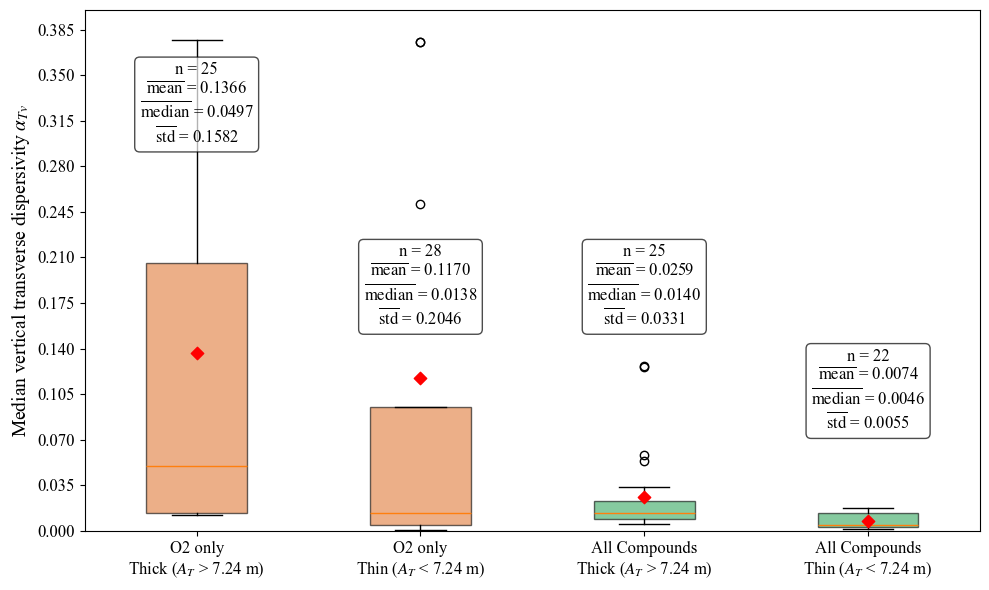

In [4]:
# ----------------------------------------------------------------------
# 1. Load data
# ----------------------------------------------------------------------

SHEET_NAME = "Data"

data = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
data = data.rename(columns={"Site ID": "Site_ID", "Aquifer thickness": "AT"})

# ----------------------------------------------------------------------
# 1b. Build alpha (atv) table from the per-fraction sheets
# ----------------------------------------------------------------------
FRACTIONS = ["0.1", "0.2", "0.4", "0.5", "0.6", "0.8", "1.0"]

def load_atv_long(prefix):
    """Stack Site_ID/atv from all fraction sheets for a given suffix ('O2' or 'All')."""
    frames = []
    for frac in FRACTIONS:
        sheet = f"{frac}_{prefix}"
        df = pd.read_excel(EXCEL_PATH, sheet_name=sheet)
        df = df[["Site_ID", "atv"]].copy()
        df["Site_ID"] = pd.to_numeric(df["Site_ID"], errors="coerce")
        df["atv"] = pd.to_numeric(df["atv"], errors="coerce")
        df = df.dropna(subset=["Site_ID"])
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out["Site_ID"] = out["Site_ID"].astype(int)
    return out

alpha_O2_long  = load_atv_long("O2")
alpha_All_long = load_atv_long("All")

# ----------------------------------------------------------------------
# 2. ONE median alpha value per site
# ----------------------------------------------------------------------
alpha_O2_stats = alpha_O2_long.groupby("Site_ID", as_index=False).agg(
    Alpha_O2_median=("atv", "median"),
    Alpha_O2_mean=("atv", "mean"),
    n_rounds_O2=("atv", "count"),
)

alpha_All_stats = alpha_All_long.groupby("Site_ID", as_index=False).agg(
    Alpha_AllCompounds_median=("atv", "median"),
    Alpha_AllCompounds_mean=("atv", "mean"),
    n_rounds_All=("atv", "count"),
)

alpha_med = alpha_O2_stats.merge(alpha_All_stats, on="Site_ID", how="outer")

# ----------------------------------------------------------------------
# 3. Aquifer-thickness mean and classification
# ----------------------------------------------------------------------
AT_mean = data["AT"].mean()
print(f"Aquifer Thickness statistics (n = {len(data)}):")
print(f"  Mean   = {AT_mean:.2f} m")
print(f"  Median = {data['AT'].median():.2f} m")
print(f"  Std    = {data['AT'].std():.2f} m")
print("-" * 70)

data["Class"] = np.where(data["AT"] > AT_mean, "Thick (AT > mean)", "Thin (AT < mean)")

merged = alpha_med.merge(data[["Site_ID", "AT", "Class"]], on="Site_ID", how="inner")

# ----------------------------------------------------------------------
# 4. Helper: print site lists + stats, return per-site median & mean arrays
# ----------------------------------------------------------------------
def summarize_and_split(df, median_col, mean_col, label):
    print(f"\n===== {label} (per site) =====")
    groups = {}
    for cls in ["Thick (AT > mean)", "Thin (AT < mean)"]:
        sub = df[df["Class"] == cls].dropna(subset=[median_col, mean_col]).sort_values("Site_ID")
        med_vals = sub[median_col].values
        mean_vals = sub[mean_col].values
        groups[cls] = {"median_vals": med_vals, "mean_vals": mean_vals}

        print(f"\n-- {cls} --")
        print(f"  n sites = {len(med_vals)}")
        if len(med_vals) > 0:
            print(f"  Median of medians = {np.median(med_vals):.6f}")
            print(f"  Mean of medians   = {np.mean(med_vals):.6f}")
            print(f"  Std (of medians)  = {np.std(med_vals, ddof=1):.6f}" if len(med_vals) > 1 else "  Std = NA")
    return groups

groups_O2 = summarize_and_split(merged, "Alpha_O2_median", "Alpha_O2_mean", "O2 only")
groups_All = summarize_and_split(merged, "Alpha_AllCompounds_median", "Alpha_AllCompounds_mean", "All Compounds")

# ----------------------------------------------------------------------
# 5. Combined boxplot — built from per-site MEDIAN values
#    Diamond marker overlaid separately = MEAN of per-site MEDIANS
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

groups_list = [
    groups_O2["Thick (AT > mean)"],
    groups_O2["Thin (AT < mean)"],
    groups_All["Thick (AT > mean)"],
    groups_All["Thin (AT < mean)"],
]

box_data = [g["median_vals"] for g in groups_list]

tick_labels = [
    f"O2 only\nThick ($A_T$ > {AT_mean:.2f} m)",
    f"O2 only\nThin ($A_T$ < {AT_mean:.2f} m)",
    f"All Compounds\nThick ($A_T$ > {AT_mean:.2f} m)",
    f"All Compounds\nThin ($A_T$ < {AT_mean:.2f} m)",
]

bp = ax.boxplot(box_data, tick_labels=tick_labels,
                 patch_artist=True, showmeans=False)

COLOR_O2  = "#E07B39"
COLOR_ALL = "#36A75F"
colors = [COLOR_O2, COLOR_O2, COLOR_ALL, COLOR_ALL]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# ---- Manually overlay MEAN-OF-MEDIANS as red diamond ----
for i, g in enumerate(groups_list, start=1):
    med_vals = g["median_vals"]
    if len(med_vals) > 0:
        ax.scatter(i, np.mean(med_vals), marker="D", color="red",
                   edgecolor="red", s=40, zorder=5)

ax.set_ylabel(r"Median vertical transverse dispersivity $\alpha_{Tv}$ ", fontsize=14)

Y_TOP = 0.4
ax.set_ylim(bottom=0, top=Y_TOP)
ax.set_yticks(np.arange(0, Y_TOP + 0.001, 0.035))

annotation_y_positions = [
    0.90,   # O2 only - Thick    (fraction of plot height: 1.0 = top edge)
    0.55,   # O2 only - Thin
    0.55,   # All Compounds - Thick
    0.35,   # All Compounds - Thin
]

# ---- Annotate with overline notation (mean of medians) ----
for i, (g, y_pos) in enumerate(zip(groups_list, annotation_y_positions), start=1):
    med_vals = g["median_vals"]
    n = len(med_vals)
    if n > 0:
        lines = [f"n = {n}"]
        lines.append(r"$\overline{\mathrm{mean}}$" + f" = {np.mean(med_vals):.4f}")
        lines.append(r"$\overline{\mathrm{median}}$" + f" = {np.median(med_vals):.4f}")
        if n > 1:
            lines.append(r"$\overline{\mathrm{std}}$" + f" = {np.std(med_vals, ddof=1):.4f}")
        txt = "\n".join(lines)
        ax.text(i, y_pos, txt, ha="center", va="top", fontsize=12,
                transform=ax.get_xaxis_transform(),
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.xticks(fontsize=12)
plt.tight_layout()
plt.savefig("fig5.pdf", dpi=300, bbox_inches="tight")
print("\nCombined boxplot figure saved to: Fig.5.pdf")